# One-Hot Encoding

Most ML algorithms only understand numbers. Columns like `Gender` (`Male`/`Female`) or `Married` (`Yes`/`No`) are **categorical** — text labels with no numeric meaning. Before we can feed them to a model, we need to turn them into numbers *without inventing a false ordering* (e.g. `Male=0, Female=1` would wrongly imply `Female > Male`).

**One-hot encoding** solves this by turning each category into its own binary (0/1) column instead of a single numeric column. This notebook works through it two ways on the `loans.csv` dataset:

1. `pandas.get_dummies()` — quick, good for exploration.
2. `sklearn.preprocessing.OneHotEncoder` — the version you actually want in a real ML pipeline (fit on train, reuse on test/production).

Along the way we also cover why missing values need to be handled first, the "dummy variable trap," and when to reach for one-hot encoding vs. its alternatives.

In [32]:
import pandas as pd

Just pandas — everything below (`read_csv`, `isnull`, `fillna`, `get_dummies`) is a DataFrame/Series method.

In [33]:
dataset = pd.read_csv("loans.csv")
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y
3,LP001004,Male,Yes,0,Graduate,No,5069.0,0,218.0,360.0,1.0,Semiurban,Y
4,LP001005,Male,No,2,Graduate,No,3002.0,2283,194.0,360.0,0.0,Urban,N


`read_csv` loads `loans.csv` into a DataFrame; `head()` prints the first 5 rows so we can eyeball the columns before doing anything else.

Scanning the output, the columns split into two groups:

| Type | Columns |
|---|---|
| Categorical (text labels) | `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Property_Area`, `Loan_Status` |
| Numeric | `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History` |

This notebook focuses on encoding `Gender` and `Married` — the same technique applies to the rest.

In [34]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

`isnull()` turns every cell into `True`/`False` (missing or not), and `.sum()` adds those booleans column-wise (`True` counts as 1) — a one-liner for "how many NaNs per column."

This has to happen **before** encoding, not after, because both encoders choke on `NaN` in different ways:

- `pd.get_dummies()` will silently drop `NaN` rows into *no* category (all encoded columns become 0) unless you pass `dummy_na=True` — easy to miss.
- `sklearn.OneHotEncoder` raises an error on `NaN` by default (unless you set `handle_unknown`/`encoded_missing_value`).

So: impute first, encode second.

In [35]:
dataset["Gender"] = dataset["Gender"].fillna(dataset["Gender"].mode()[0])

`.mode()[0]` is the most frequent value in the column — the standard way to impute a **categorical** column (compare: numeric columns are usually filled with `.median()` or `.mean()`).

Note the fix from the copy-on-write gotcha we hit earlier: `dataset["Gender"].fillna(value, inplace=True)` mutates a throwaway copy of the column and silently does nothing to `dataset`. Reassigning — `dataset["Gender"] = dataset["Gender"].fillna(value)` — writes the result back into the real DataFrame.

In [38]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

`Gender` now reads `0`. (This particular output also shows `Married` at `0` — that's a leftover from an earlier out-of-order run, not a real effect of the `Gender` fillna. If you `Restart & Run All` top-to-bottom, `Married` will still show its original missing count here, since its own `fillna` cell hasn't executed yet at this point in the notebook — worth remembering when a notebook's outputs stop matching its cell order.)

The remaining columns are left untouched — out of scope here since we're only encoding `Gender` and `Married`.

In [37]:
dataset["Married"] = dataset["Married"].fillna(dataset["Married"].mode()[0])

Same pattern as `Gender` — mode imputation, reassigned rather than `inplace=True`.

In [39]:
en_data = dataset[["Gender","Married"]]
en_data

,Gender,Married
0,Male,Yes
1,Male,Yes
2,Female,No
3,Male,Yes
4,Male,No
...,...,...
613,Female,Yes
614,Male,Yes
615,Male,No
616,Male,Yes


Pulling out just the two columns we're going to encode. Both are **nominal** categorical variables — categories with no inherent order (`Male` isn't "more" or "less" than `Female`). That distinction matters:

- **Nominal** (`Gender`, `Married`, `Property_Area`, ...) → one-hot encode.
- **Ordinal** (e.g. an education level `High School < Bachelors < Masters`) → encode as ordered integers instead (`OrdinalEncoder`), so the model can actually use the ordering. One-hotting an ordinal column throws away information the model could have used.

`Dependents`, `Education`, `Property_Area`, and `Loan_Status` are also categorical in this dataset and would follow the exact same recipe — left out here just to keep the example focused.

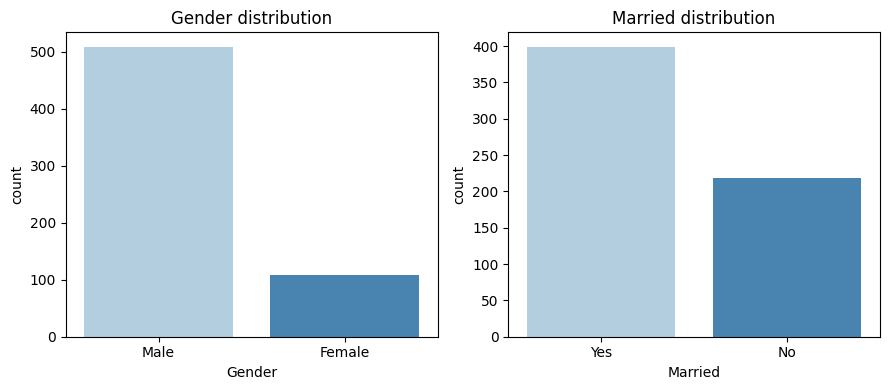

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.countplot(x="Gender", data=en_data, hue="Gender", legend=False, palette="Blues", ax=axes[0])
axes[0].set_title("Gender distribution")
sns.countplot(x="Married", data=en_data, hue="Married", legend=False, palette="Blues", ax=axes[1])
axes[1].set_title("Married distribution")
plt.tight_layout()
plt.show()

In [43]:
pd.get_dummies(en_data)

,Gender_Female,Gender_Male,Married_No,Married_Yes
0,False,True,False,True
1,False,True,False,True
2,True,False,True,False
3,False,True,False,True
4,False,True,True,False
...,...,...,...,...
613,True,False,False,True
614,False,True,False,True
615,False,True,True,False
616,False,True,False,True


`pd.get_dummies()` looks at every unique value in each column and creates one binary column per value:

- `Gender` (2 unique values) → `Gender_Female`, `Gender_Male`
- `Married` (2 unique values) → `Married_No`, `Married_Yes`

Each row gets exactly one `True` per original column — that single "hot" (on) bit among otherwise-zero columns is where the name comes from.

**Watch this:** `Gender_Female` and `Gender_Male` are perfect opposites — if you know one, you automatically know the other (`Male = NOT Female`). Keeping both is redundant and, for linear models, actively harmful (it's called the **dummy variable trap** — more on this further down, where `drop="first"` fixes it).

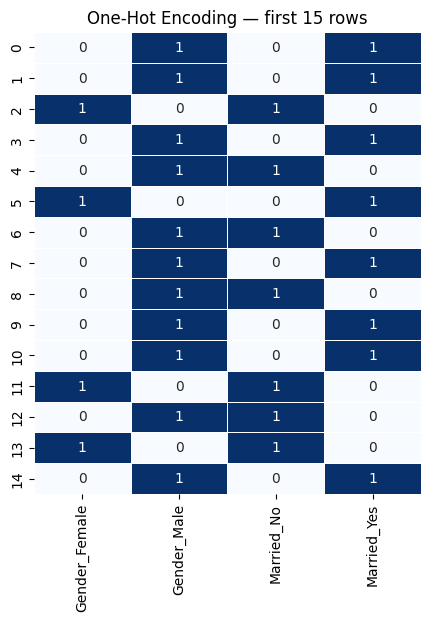

In [42]:
sample = pd.get_dummies(en_data).head(15).astype(int)

plt.figure(figsize=(5, 6))
sns.heatmap(sample, annot=True, cmap="Blues", cbar=False, linewidths=0.5, linecolor="white")
plt.title("One-Hot Encoding — first 15 rows")
plt.show()

In [44]:
pd.get_dummies(en_data).info()

<class 'pandas.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Gender_Female  618 non-null    bool 
 1   Gender_Male    618 non-null    bool 
 2   Married_No     618 non-null    bool 
 3   Married_Yes    618 non-null    bool 
dtypes: bool(4)
memory usage: 2.5 KB


The encoded columns are `bool`, not `int` — `True`/`False` instead of `1`/`0`. That's a memory optimization (1 byte per bool vs. 8 bytes for a default `int64`); 618 rows × 4 columns fits in 2.5 KB. Most ML libraries treat `True`/`False` as `1`/`0` automatically, but if something insists on numeric dtype, `.astype(int)` converts them explicitly.

In [18]:
from sklearn.preprocessing import OneHotEncoder

Why a second way to do the same thing? `pd.get_dummies()` is convenient for a one-off notebook, but it doesn't *remember* what it did — it just looks at whatever data you hand it *right now* and creates columns for whatever categories happen to be present. Two problems that causes in real ML work:

- If your test/production data has a category that never showed up in training, `get_dummies()` won't create a column for it, and your train/test column counts will mismatch.
- If a category is missing from a later batch, you lose a column that your trained model still expects.

`OneHotEncoder` fixes this with the same **fit / transform** contract every sklearn transformer follows: `fit()` learns the fixed set of categories once (like compiling a schema), and `transform()` applies *that exact schema* to any new data afterward — erroring or ignoring cleanly on anything unseen, depending on `handle_unknown`. That's what makes it safe to drop into a `Pipeline`/`ColumnTransformer` and reuse between training and inference.

In [26]:
ohe = OneHotEncoder()
ohe.fit_transform(en_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1236 stored elements and shape (618, 4)>

Notice the return type: not an array, not a DataFrame — a **sparse matrix** (`Compressed Sparse Row`, or CSR). One-hot encoded data is mostly zeros (only one column per category-group is ever "hot"), so instead of storing every zero, sklearn stores just the non-zero coordinates and values.

`1236 stored elements, shape (618, 4)`: 618 rows × 2 encoded groups (`Gender`, `Married`) × 1 active flag per group = 1236 ones. A dense array here would allocate 618 × 4 = 2472 cells — noticeably more, and the savings scale up fast with higher-cardinality columns (e.g. one-hotting a `zip_code` column with 40,000 unique values would be nearly all zeros).

In [27]:
ohe.fit_transform(en_data).toarray()

array([[0., 1., 0., 1.],
       [0., 1., 0., 1.],
       [1., 0., 1., 0.],
       ...,
       [0., 1., 1., 0.],
       [0., 1., 0., 1.],
       [0., 1., 0., 1.]], shape=(618, 4))

`.toarray()` expands the sparse matrix back into a regular dense NumPy array — every implicit zero gets written out. Fine for peeking at the data here; in a real pipeline you'd generally leave it sparse (or construct with `OneHotEncoder(sparse_output=False)` if you specifically need dense) since most sklearn estimators accept sparse input directly and there's no reason to pay the memory cost.

In [28]:
ar = ohe.fit_transform(en_data).toarray()
pd.DataFrame(ar, columns=["Gender_Female","Gender_Male","Married_No","Married_Yes"])

,Gender_Female,Gender_Male,Married_No,Married_Yes
0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0
2,1.0,0.0,1.0,0.0
3,0.0,1.0,0.0,1.0
4,0.0,1.0,1.0,0.0
...,...,...,...,...
613,1.0,0.0,0.0,1.0
614,0.0,1.0,0.0,1.0
615,0.0,1.0,1.0,0.0
616,0.0,1.0,0.0,1.0


Column names are hardcoded by hand here — fragile, since it depends on knowing the exact category order sklearn picked. The robust way to get them is `ohe.get_feature_names_out(["Gender", "Married"])`, which returns the real column names sklearn assigned, in the right order, straight from the fitted encoder.

In [30]:
ohe = OneHotEncoder(drop="first")
ohe.fit_transform(en_data)
ohe.fit_transform(en_data).toarray()

array([[1., 1.],
       [1., 1.],
       [0., 0.],
       ...,
       [1., 0.],
       [1., 1.],
       [1., 1.]], shape=(618, 2))

This is the dummy-variable-trap fix mentioned earlier. `drop="first"` drops one category per original column instead of keeping all of them:

- `Gender` (`Female`, `Male`) → drops `Female` alphabetically, keeps only `Gender_Male`. `0` now *means* `Female`.
- `Married` (`No`, `Yes`) → drops `No`, keeps only `Married_Yes`. `0` now means `No`.

**Why it matters:** with *all* categories kept, the columns are perfectly collinear (`Gender_Female = 1 − Gender_Male`), which makes the design matrix rank-deficient for linear/logistic regression — the math for inverting it breaks down, and coefficient estimates become unstable. Dropping one category per group removes the redundancy without losing information: the dropped category is still fully represented, just implicitly, as "all other flags in this group are 0."

Tree-based models (decision trees, random forests, XGBoost) don't do this matrix inversion, so they're unaffected by the trap — you can leave `drop="first"` off for them if you'd rather keep the encoding symmetric.

In [31]:
ar = ohe.fit_transform(en_data).toarray()
pd.DataFrame(ar, columns=["Gender_Male","Married_Yes"])

,Gender_Male,Married_Yes
0,1.0,1.0
1,1.0,1.0
2,0.0,0.0
3,1.0,1.0
4,1.0,0.0
...,...,...
613,0.0,1.0
614,1.0,1.0
615,1.0,0.0
616,1.0,1.0


That's the full round trip: raw text categories → missing values imputed → one-hot encoded → collinearity-safe encoding via `drop="first"`. Summary of when to reach for this below.

## When to Use One-Hot Encoding

**Use it when:**
- The categorical variable is **nominal** (no order) — `Gender`, `Married`, `Property_Area`, `Color`, `Country`, etc.
- The model is **distance- or weight-based** and would otherwise misread integer-coded categories as having magnitude/order: linear & logistic regression, SVM, KNN, k-means, and neural networks all fall into this bucket. Feeding `Property_Area = {Rural: 0, Semiurban: 1, Urban: 2}` into linear regression tells the model `Urban` is "twice" `Semiurban` — nonsense for an unordered category. One-hot avoids that entirely.

**Think twice when:**
- **The category is ordinal.** An education level with a real ranking should use `OrdinalEncoder` (or a manual integer map) instead — one-hot throws away the order information the model could use.
- **Cardinality is high** (dozens/hundreds/thousands of unique values — think `zip_code`, `user_id`, `product_sku`). One-hot then explodes column count, which:
  - blows up memory/compute (mitigated somewhat by sparse matrices, as seen above, but still)
  - creates a lot of very sparse, low-signal columns that hurt models prone to overfitting
  - Alternatives: **target/mean encoding**, **frequency encoding**, the **hashing trick**, or learned **embeddings** (common in deep learning / recommendation systems).
- **Tree-based models with many categories.** Random forests / gradient boosting *can* consume one-hot columns, but they often perform just as well or better with plain integer-encoded categories (or native categorical support, e.g. `HistGradientBoostingClassifier`, LightGBM, CatBoost) — trees split on thresholds, so they don't assume distance between codes the way linear models do.

**Implementation notes:**
- `pd.get_dummies()` — fast for one-off EDA in a notebook; not schema-stable across separate train/test calls.
- `sklearn.OneHotEncoder` — the one to use in an actual pipeline: `fit` on train, `transform` on test/production so both see identical columns; set `handle_unknown="ignore"` to avoid blowing up on a category the model has never seen in production; combine with `ColumnTransformer` to encode some columns while leaving numeric ones alone.
- Use `drop="first"` (or `drop="if_binary"`) for linear/logistic regression to sidestep the dummy variable trap; leave it off for tree-based models or when you specifically want every category explicitly represented.